(07-37-llms-en-efficientie)=

# LLM's, advies en efficiëntie

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 2022–2026: van de lancering van ChatGPT op 30 november 2022 tot
het moment waarop Santa-Clara zijn terugblik schreef.

**Wat we al weten.** [De vorige lecture](#06-36-inelastische-markten) liet zien
dat het geaggregeerde aandelenniveau wordt gezet door geldstromen die op een
inelastische vraag stuiten, niet door een arbitrageur die de fundamentele waarde
kent. Daarvoor had [machine learning](#06-35-machine-learning) de cross-sectie
voorspeld zonder te zeggen waarom. En al in
[de lecture over efficiënte markten](#02-06-efficiente-markten) stond de paradox
van Grossman en Stiglitz: een prijs kan niet alle informatie bevatten als
informatie geld kost.

**Welke vraag staat open.** Wat gebeurt er met beleggingsadvies en met de
efficiëntie van prijzen als het lezen, samenvatten en interpreteren van
informatie bijna niets meer kost?
```

## Overzicht

Santa-Clara sluit zijn geschiedenis af met de vraag wat de volgende machine doet, en
presenteert zijn antwoord als verwachting, niet als bevinding {cite}`SantaClara2026`.
Krijgen particulieren beter advies nu een taalmodel het werk van een adviseur tegen nul
marginale kosten doet? En worden markten efficiënter nu machines elke jaarrekening en
elk transcript binnen seconden lezen? Op de eerste vraag verwacht hij een betere mediaan
en een slechtere staart, op de tweede een tweedeling: relatieve prijzen worden
efficiënter, het marktniveau niet.

Het theoretische anker is {cite:t}`GrossmanStiglitz1980`: als informatie goedkoper
wordt, worden meer beleggers geïnformeerd en verraadt de prijs meer, maar volledig
informatief wordt ze nooit zolang informatie iets kost en er ruis in de handel zit. We
leiden dat evenwicht af en voegen er twee dingen aan toe: modelfouten die veel beleggers
delen, en advies als portefeuillekeuze met een adviseur wiens belang afwijkt van dat van
de klant. Daaromheen staat het empirische werk over robo-advies
{cite}`DAcuntoPrabhalaRossi2019`, handel door aandacht
{cite}`BarberHuangOdeanSchwarz2022`, ChatGPT als nieuwslezer {cite}`LopezLiraTang2023`,
bedrijven die voor machines schrijven {cite}`CaoJiangYangZhang2023` en de koersreactie
op ChatGPT zelf {cite}`EisfeldtSchubertZhang2023`.

Aan het eind repliceren we een event study in de geest van Eisfeldt, Schubert en Zhang
rond 30 november 2022, met 50 grote Amerikaanse aandelen die we zelf indelen naar
blootstelling aan generatieve AI, en meten we de halfwaardetijd van informatie indirect
via de dagelijkse autocorrelatie van de markt per decennium sinds 1930.

```{admonition} Epistemische status van deze lecture
:class: warning

Deze lecture mengt drie soorten uitspraken. **Stellingen**: het
Grossman-Stiglitz-evenwicht en de variantie van een gemiddelde van gecorreleerde fouten
zijn wiskunde onder expliciete aannames. **Feiten**: dat robo-advies portefeuilles
veranderde, dat Robinhood-kopers verloren en dat prijzen sneller reageren dan vroeger,
is gemeten. **Speculatie**: dat taalmodellen de mediane belegger helpen, dat een
monocultuur van modellen crashes veroorzaakt en dat passief beleggen via AI het
marktniveau minder efficiënt maakt, is niet getoetst en met de huidige data ook niet
toetsbaar. Santa-Clara presenteert het zelf als verwachting. In de termen van motief 3
gaat de reeks hier over van feiten-met-concurrerende-theorieën naar
vermoedens-zonder-feiten.
```

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

**Advies.** Het standaardadvies van het vak past op een systeemkaart: spreid, houd de
kosten laag, handel weinig, verkoop niet in paniek. Het probleem was nooit de inhoud
maar de aflevering: een menselijke adviseur die het op het moment van verleiding
herhaalt, kost ongeveer één procent per jaar. Santa-Clara: *"Advice that was scarce
because it required a person now costs nothing at the margin"* {cite}`SantaClara2026`.
Omdat de mediane particulier ver van dat advies af zit — te weinig spreiding, te veel
handel, zoals [de lecture over behavioral finance](#04-23-behavioral) liet zien — helpt
zelfs een middelmatige digitale adviseur. Maar wat een klant kan afremmen, kan hem ook
aanzetten, en een platform dat per transactie verdient, heeft daar belang bij. Zijn
verwachting: *"the median investor does better [...] and the tail of gamified losses
gets worse."*

**Efficiëntie.** Informatie komt in prijzen omdat iemand ervoor betaalt en dat
terugverdient door te handelen voordat de prijs het weet. Wordt lezen en interpreteren
goedkoper, dan doen meer mensen het en bevat de prijs meer informatie. Drie dingen maken
dat goede nieuws minder eenvoudig.

Het eerste is de monocultuur. Tien analisten met elk hun eigen fouten middelen die
fouten weg; tien algoritmen die met hetzelfde soort model op dezelfde data zijn
getraind, maken dezelfde fout tegelijk. *"Correlated errors are what turn a mispricing
into a crash"*, schrijft Santa-Clara.

Het tweede is het verschil tussen relatieve en geaggregeerde prijzen. Een relatieve fout
kan een arbitrageur handelen: koop het ondergewaardeerde aandeel, verkoop het
overgewaardeerde, en het marktrisico valt weg. Tegenover een gok op het marktniveau
staat geen hedge; dat niveau wordt gezet door stromen die op een inelastisch aanbod
stuiten, en een slimmere machine verandert daar niets aan.

Het derde is de joint hypothesis. Efficiëntie betekende: prijzen zijn verwachtingen
onder het ware model. Als beleggers zelf uit hoogdimensionale data leren en dat model
niet kunnen kennen, verliest het begrip zijn houvast {cite}`MartinNagel2022`.

## Toy-voorbeeld: Grossman-Stiglitz en een monocultuur met de hand

### (a) Het evenwichtsaandeel geïnformeerden voor twee informatiekosten

Een risicovol activum betaalt $x = s + \varepsilon$, met signaal $s \sim
\mathcal{N}(\mu_s, \sigma^2_s)$ en ruis $\varepsilon \sim \mathcal{N}(0,
\sigma^2_\varepsilon)$. Een fractie $\lambda$ van de CARA-beleggers (risicoaversie $a$)
betaalt $c$ en ziet $s$; de rest ziet alleen de prijs, en het aanbod ruist met variantie
$\sigma^2_z$. De theorie hieronder geeft de *informativiteit* van de prijs, $\rho^2 =
\Corr^2(s, p)$, als functie van $\lambda$:

$$
\rho^2(\lambda) = \frac{\lambda^2}{\lambda^2 + m},
\qquad m = \frac{a^2 \sigma^4_\varepsilon \sigma^2_z}{\sigma^2_s}.
$$

En in een evenwicht waarin beide typen voorkomen, moet gelden

$$
1 - \rho^2 = k, \qquad k = \frac{\sigma^2_\varepsilon}{\sigma^2_s}\left(e^{2ac} - 1\right).
$$

Neem $a = 2$, $\sigma^2_s = \sigma^2_\varepsilon = 1$ en $\sigma^2_z = 0{,}04$.
Dan is $m = 4 \times 1 \times 0{,}04 / 1 = 0{,}16$.

**Dure informatie**, $c = \ln(1{,}5)/4 \approx 0{,}101$: $e^{2ac} = 1{,}5$ en $k =
0{,}5$, dus $\rho^2 = 0{,}5$, en $\lambda^2/(\lambda^2 + 0{,}16) = 0{,}5$ geeft
$\lambda^2 = 0{,}16$, dus $\lambda = 0{,}4$.

**Goedkope informatie**, $c = \ln(1{,}2)/4 \approx 0{,}046$: $k = 0{,}2$, dus $\rho^2 =
0{,}8$, en $\lambda^2/(\lambda^2 + 0{,}16) = 0{,}8$ geeft $\lambda^2 = 0{,}64$, dus
$\lambda = 0{,}8$.

Ruim de helft goedkopere informatie verdubbelt het aandeel geïnformeerden. De
restvariantie van de payoff voor wie alleen de prijs ziet, $\sigma^2_\varepsilon
e^{2ac}$ (1,5 of 1,2, tegen 1,0 voor een geïnformeerde), is in nut precies $c$ waard.

In [2]:
def gs_equilibrium(c, a, var_s, var_e, var_z):
    """Grossman-Stiglitz (1980) CARA-normal equilibrium.

    Returns the fraction of informed traders lam, price informativeness
    rho2 = Corr^2(s, p) and the gross certainty-equivalent value of the signal.
    """
    m = a**2 * var_e**2 * var_z / var_s
    k = var_e / var_s * np.expm1(2 * a * c)
    if k >= 1:
        lam = 0.0
    elif k <= 0:
        lam = 1.0
    else:
        lam = min(1.0, np.sqrt(m * (1 - k) / k))
    rho2 = lam**2 / (lam**2 + m)
    value = np.log1p(var_s * (1 - rho2) / var_e) / (2 * a)
    return lam, rho2, value


a, var_s, var_e, var_z = 2.0, 1.0, 1.0, 0.04
toy_gs = pd.DataFrame(
    [dict(zip(["c", "lambda", "rho2", "waarde signaal"], [np.log(g) / 4, *gs_equilibrium(np.log(g) / 4, a, var_s, var_e, var_z)]))
     for g in (1.5, 1.2)],
    index=["dure informatie", "goedkope informatie"],
)
assert np.allclose(toy_gs[["lambda", "rho2"]].to_numpy(), [[0.4, 0.5], [0.8, 0.8]])
assert np.allclose(toy_gs["waarde signaal"], toy_gs["c"])
toy_gs.round(4)

,c,lambda,rho2,waarde signaal
dure informatie,0.1014,0.4,0.5,0.1014
goedkope informatie,0.0456,0.8,0.8,0.0456


### (b) Vier arbitrageurs, gedeelde of eigen fouten

Vier arbitrageurs schatten de waarde van een aandeel. Elk maakt een fout van
$+1$ of $-1$ met kans $\tfrac12$, dus elk heeft variantie 1: ze zijn individueel
even nauwkeurig. De prijs is hun gemiddelde schatting.

**Eigen modellen.** Van de $2^4 = 16$ even waarschijnlijke combinaties van
onafhankelijke fouten geeft er één een gemiddelde van $-1$, vier $-\tfrac12$, zes $0$,
vier $+\tfrac12$ en één $+1$. De variantie is $2 \cdot \tfrac1{16} + 2 \cdot \tfrac4{16}
\cdot \tfrac14 = \tfrac14$, en de kans op de grootste daling is $\tfrac1{16} =
6{,}25\%$.

**Eén model.** Alle vier gebruiken hetzelfde model en maken dezelfde fout. Het
gemiddelde is $\pm 1$ met kans $\tfrac12$: variantie 1 en een kans van 50% op de
grootste daling.

**Half-half.** Twee delen een model, twee hebben een eigen model. Het gemiddelde is
$(2f + u_3 + u_4)/4$ met variantie $(4 + 1 + 1)/16 = 0{,}375$; de grootste daling
vereist $f = u_3 = u_4 = -1$, kans $\tfrac18$.

De algemene regel, die we hieronder bewijzen, is $\Var = \rho^2 + (1-\rho)/N$ met
$\rho$ de fractie die het model deelt: $\tfrac14$, $0{,}375$ en $1$.

In [3]:
def average_error_distribution(n, n_shared):
    """Exact distribution of the mean of n +-1 errors when n_shared traders share one draw."""
    n_draws = n - n_shared + (1 if n_shared else 0)
    dist = {}
    for d in itertools.product([-1, 1], repeat=n_draws):
        total = d[0] * n_shared + sum(d[1:]) if n_shared else sum(d)
        dist[total / n] = dist.get(total / n, 0.0) + 0.5**n_draws
    return pd.Series(dist).sort_index()


toy_mono = pd.DataFrame(
    {label: {"variantie": (dist := average_error_distribution(4, k)) @ dist.index.to_numpy() ** 2,
             "formule rho^2 + (1-rho)/N": (k / 4) ** 2 + (1 - k / 4) / 4,
             "P(grootste daling)": dist.loc[-1.0]}
     for label, k in [("eigen modellen", 0), ("half-half", 2), ("een model", 4)]}
).T
assert np.allclose(toy_mono["variantie"], [0.25, 0.375, 1.0])
assert np.allclose(toy_mono["P(grootste daling)"], [1 / 16, 1 / 8, 1 / 2])
toy_mono.round(4)

,variantie,formule rho^2 + (1-rho)/N,P(grootste daling)
eigen modellen,0.250,0.250,0.0625
half-half,0.375,0.375,0.1250
een model,1.000,1.000,0.5000


De code reproduceert beide handberekeningen exact. In (b) is elke arbitrageur steeds
even nauwkeurig; alleen de samenhang van de fouten verandert, en die bepaalt de staart.

## Theorie

### Opzet: CARA, normaliteit en ruis in het aanbod

We volgen {cite:t}`GrossmanStiglitz1980` in de notatie van deze reeks (zij schrijven
$\theta$ voor het signaal en $x$ voor het aanbod, wij $s$ en $z$). Er is één periode,
een risicovrij activum met rente nul, en een risicovol activum met payoff $x = s +
\varepsilon$. Beleggers hebben nut $u(W) = -e^{-aW}$, en het aanbod per belegger is $z
\sim \mathcal{N}(\bar z, \sigma^2_z)$, onafhankelijk van $s$ en $\varepsilon$. Zonder
die ruis zou de prijs het signaal volledig verraden, zou niemand voor informatie
betalen, en bestond er geen evenwicht.

Een CARA-belegger met normaal verdeelde payoff kiest de vraag $D = (\E[x \mid
\mathcal{I}] - p)/(a \Var(x \mid \mathcal{I}))$. Voor een geïnformeerde is
$\mathcal{I} = \{s, p\}$ en dus $D_I = (s - p)/(a\sigma^2_\varepsilon)$; voor een
ongeïnformeerde is $\mathcal{I} = \{p\}$.

### Het evenwicht

*Waarom zou dit waar zijn?* Geïnformeerden handelen op $s$, dus de prijs draagt een
spoor van $s$. Omdat het aanbod ruist, weet een ongeïnformeerde niet of een hoge prijs
goed nieuws of weinig aanbod betekent; hoe meer geïnformeerden, hoe minder ruizig het
spoor. In evenwicht laat de keuze om voor $s$ te betalen iedereen onverschillig.

:::{prf:proposition} Grossman-Stiglitz-evenwicht
:label: thm-llms-en-efficientie-gs

Definieer $w = s - \frac{a\sigma^2_\varepsilon}{\lambda}(z - \bar z)$ voor
$\lambda > 0$. Dan geldt:

1. Er is een lineair evenwicht met prijs $p = \pi_0 + \pi_1 w$, en $p$ en $w$
   bevatten dezelfde informatie. De informativiteit van de prijs is

   ```{math}
   :label: eq-llms-en-efficientie-rho
   \rho^2(\lambda) \equiv \Corr^2(s, w) = \frac{\lambda^2}{\lambda^2 + m},
   \qquad m = \frac{a^2\sigma^4_\varepsilon\sigma^2_z}{\sigma^2_s}.
   ```

2. Voor elke $w$ is de verhouding van de verwachte nutten van een geïnformeerde en
   een ongeïnformeerde belegger

   ```{math}
   :label: eq-llms-en-efficientie-ratio
   \frac{\E[u(W_I) \mid w]}{\E[u(W_U) \mid w]} = e^{ac}\sqrt{\frac{\sigma^2_\varepsilon}{\Var(x \mid w)}},
   \qquad \Var(x \mid w) = \sigma^2_\varepsilon + \sigma^2_s\bigl(1 - \rho^2(\lambda)\bigr).
   ```

3. Met $k = (\sigma^2_\varepsilon/\sigma^2_s)(e^{2ac} - 1)$ is het evenwichtsaandeel
   geïnformeerden

   ```{math}
   :label: eq-llms-en-efficientie-lambda
   \lambda^* =
   \begin{cases}
   0 & k \ge 1,\\
   \min\Bigl\{1,\ \sqrt{m(1-k)/k}\Bigr\} & 0 < k < 1,
   \end{cases}
   ```

   en in een inwendig evenwicht ($0 < \lambda^* < 1$) is $\rho^2 = 1 - k$.
:::

:::{prf:proof}
:class: dropdown

*Deel 1.* Veronderstel $p = \pi_0 + \pi_1 w$ met $\pi_1 \neq 0$. Dan is $w$ uit
$p$ te berekenen en omgekeerd. Omdat $\Cov(s, w) = \sigma^2_s$ en
$\Var(w) = \sigma^2_s + (a\sigma^2_\varepsilon/\lambda)^2\sigma^2_z$, is
$\Corr^2(s,w) = \sigma^2_s/\Var(w) = \lambda^2/(\lambda^2 + m)$. De normale
projectie geeft $\E[x \mid w] = \mu_s + \rho^2(w - \mu_s)$ en $\Var(x \mid w) =
\sigma^2_\varepsilon + \sigma^2_s(1-\rho^2)$.

Marktclearing is $\lambda D_I + (1-\lambda) D_U = z$. Schrijf $\lambda s/(a
\sigma^2_\varepsilon) - z = \frac{\lambda}{a\sigma^2_\varepsilon} w - \bar z$. Dan
wordt de clearingvoorwaarde

$$
p\left[\frac{\lambda}{a\sigma^2_\varepsilon} + \frac{1-\lambda}{a\Var(x\mid w)}\right]
= \frac{\lambda}{a\sigma^2_\varepsilon}\,w - \bar z
+ \frac{(1-\lambda)\bigl(\mu_s + \rho^2(w - \mu_s)\bigr)}{a\Var(x\mid w)},
$$

die lineair is in $w$. Dat bevestigt de gok, met $\pi_1 > 0$.

*Deel 2.* Een geïnformeerde met beginvermogen $W_0$ die de optimale vraag kiest,
heeft conditioneel op $(s, w)$ nut
$-\exp\bigl(-a(W_0 - c) - (s - p)^2/(2\sigma^2_\varepsilon)\bigr)$. Neem de
verwachting over $s$ gegeven $w$, met $s - p \mid w \sim \mathcal{N}(\E[x\mid w] - p,
\sigma^2_s(1-\rho^2))$. Voor $Y \sim \mathcal{N}(\mu, v)$ is
$\E[e^{-Y^2/(2\sigma^2)}] = \sqrt{\sigma^2/(\sigma^2 + v)}\,e^{-\mu^2/(2(\sigma^2 + v))}$,
en $\sigma^2_\varepsilon + \sigma^2_s(1-\rho^2) = \Var(x\mid w)$. Dus

$$
\E[u(W_I)\mid w] = -e^{-a(W_0 - c)}\sqrt{\frac{\sigma^2_\varepsilon}{\Var(x \mid w)}}
\exp\left(-\frac{(\E[x\mid w] - p)^2}{2\Var(x\mid w)}\right).
$$

De ongeïnformeerde heeft hetzelfde zonder de factor $e^{ac}$ en zonder de wortel.
De verhouding is [](#eq-llms-en-efficientie-ratio), en die hangt niet van $w$ af.

*Deel 3.* Beide nutten zijn negatief, dus een verhouding groter dan 1 betekent dat de
geïnformeerde slechter af is. Een inwendig evenwicht vereist verhouding 1, dus
$\Var(x\mid w) = \sigma^2_\varepsilon e^{2ac}$ en $1 - \rho^2 = k$. Invullen in
[](#eq-llms-en-efficientie-rho) geeft $\lambda^2 = m(1-k)/k$. Is dat groter dan 1, dan
blijft informatie ook met iedereen geïnformeerd strikt de moeite waard en is $\lambda^*
= 1$; is $k \ge 1$, dan is ze zelfs bij een oninformatieve prijs de kosten niet waard en
is $\lambda^* = 0$. $\square$
:::

### Wat goedkopere informatie doet

*Waarom zou dit waar zijn?* Als informatie goedkoper wordt, stijgt het rendement van
geïnformeerd zijn, en treden er beleggers toe tot hun handel de prijs zo informatief
heeft gemaakt dat het extra rendement weer precies de kosten dekt. De prijs absorbeert
de besparing.

Uit [](#eq-llms-en-efficientie-lambda) volgen drie eigenschappen.

**Monotoon.** $k$ stijgt in $c$, dus $\lambda^*$ en $\rho^2 = 1-k$ dalen in $c$:
goedkopere informatie geeft meer geïnformeerden en een informatievere prijs.

**Ruis bepaalt de deelname, niet de informativiteit.** In een inwendig evenwicht is
$\rho^2 = 1 - k$, en $k$ bevat $\sigma^2_z$ niet. Meer ruis trekt meer geïnformeerden
aan ($\lambda^* \propto \sigma_z$), en hun extra handel compenseert de extra ruis
precies. De noise traders van {cite:t}`DeLongShleiferSummersWaldmann1990` uit
[](#04-23-behavioral) zijn in dit model geen vijand van efficiëntie maar de voorwaarde
ervoor.

**De grens.** Bij $c \to 0$ gaat $\lambda^* \to 1$, maar ook dan is $\rho^2 = 1/(1+m) <
1$: wie $s$ kent, handelt zo voorzichtig dat de ruis zichtbaar blijft. De prijs wordt
dan niet meer tegengehouden door de kostprijs van informatie maar door risicoaversie en
fundamentele onzekerheid, $a$ en $\sigma^2_\varepsilon$ in $m$. Een taalmodel verlaagt
$c$; het verlaagt $\sigma^2_\varepsilon$ niet.

### Relatieve en geaggregeerde fouten: de factorstructuur van modelfouten

*Waarom zou dit waar zijn?* Grossman en Stiglitz nemen aan dat alle geïnformeerden
hetzelfde ware signaal zien. In werkelijkheid maakt elke belegger een eigen schatting
met een eigen model. Verschillen de modellen, dan middelen hun fouten weg; lijken ze op
elkaar, dan niet. Goedkopere informatie verkleint de eigen fout van elk model, niet de
gedeelde, en die kan door een handvol dominante taalmodellen juist groeien.

:::{prf:proposition} Variantie van de geaggregeerde fout
:label: thm-llms-en-efficientie-mono

$N$ arbitrageurs schatten een waarde met fout $e_i$, elk met variantie $\sigma^2$.
Een fractie $\rho$ gebruikt hetzelfde model en maakt dezelfde fout $f$; de overige
$(1-\rho)N$ maken onafhankelijke fouten $u_i$. De prijsfout is het gemiddelde
$\bar e = \frac1N\sum_i e_i$. Dan

```{math}
:label: eq-llms-en-efficientie-mono
\Var(\bar e) = \sigma^2\left(\rho^2 + \frac{1-\rho}{N}\right).
```

Algemener: als $e_i = \sqrt{\varrho}\,f + \sqrt{1-\varrho}\,u_i$ met paarsgewijze
correlatie $\varrho$, dan $\Var(\bar e) = \sigma^2\bigl(\varrho + (1-\varrho)/N\bigr)$.
:::

:::{prf:proof}
$\bar e = \rho f + \frac1N\sum_{i \notin \text{gedeeld}} u_i$, met $\rho N$ keer
dezelfde $f$ gedeeld door $N$. De twee termen zijn onafhankelijk, dus $\Var(\bar e)
= \rho^2\sigma^2 + (1-\rho)N\sigma^2/N^2$. De tweede uitspraak is
[de clusteringformule uit de lecture over event studies](#thm-eventstudies-cluster)
met gewichten $1/N$. $\square$
:::

Bij $N \to \infty$ blijft $\rho^2\sigma^2$ over. Dezelfde logica werkt over aandelen:
schrijf de fout van een model in aandeel $j$ als $e_j = \beta_j g + \eta_j$, met $g$ een
fout die alle aandelen raakt en $\eta_j$ aandeelspecifiek. Een long-short portefeuille
met bèta nul heeft fout $\sum_j w_j\eta_j$, die wegdiversifieert; de marktportefeuille
heeft fout $\bar\beta g$, die blijft ([](#ex-llms-en-efficientie-2)).

Dat is Santa-Clara's tweedeling: *"Machines make relative prices more efficient, because
relative mispricing is what a well-funded arbitrageur can trade. Nothing about machines
makes the aggregate market more efficient, because the aggregate is set by flows meeting
inelastic supply"* {cite}`SantaClara2026`. De eerste helft is
[](#eq-llms-en-efficientie-mono) toegepast op $\eta_j$. De tweede helft is [de vorige
lecture](#06-36-inelastische-markten): als een dollar instroom de geaggregeerde waarde
met ongeveer vijf dollar verhoogt {cite}`GabaixKoijen2021,KoijenYogo2019`, bepalen
stromen het niveau. Passieve stromen, en adviseurs die klanten in dezelfde
modelportefeuilles leiden, vergroten het deel van de vraag dat niet op prijs reageert en
maken het aggregaat gevoeliger voor stromen, niet voor nieuws.

### Crowding, leverage en crashes

*Waarom zou dit waar zijn?* Een gedeelde fout wordt pas een crash als iedereen
tegelijk moet verkopen. Dat gebeurt als de handelaren niet weten hoeveel anderen
dezelfde positie hebben, en als ze die positie met geleend geld financieren.

{cite:t}`Stein2009` noemde het eerste probleem *crowding* (te veel arbitrageurs die,
zonder het van elkaar te weten, dezelfde positie innemen): voor strategieën zonder vast
fundamenteel anker kan een arbitrageur *"not know how many of his peers are
simultaneously entering the same trade"*. Het tweede is *leverage* (de verhouding tussen
positie en eigen vermogen): wie die privé optimaal kiest, *"may create a fire-sale
externality that raises the likelihood of a severe crash."* Een monocultuur van modellen
verergert het eerste: iedereen zit ongemerkt in dezelfde trade.

Het best gedocumenteerde voorbeeld ligt vóór de taalmodellen. {cite:t}`KhandaniLo2011`
bestudeerden de week van 6 augustus 2007, waarin kwantitatieve
long-short-aandelenfondsen *"experienced unprecedented losses"*. Met gesimuleerde
portefeuilles op vijf waarderingsfactoren vonden ze dat de afbouw van zulke
portefeuilles al in juli begon, en met transactiedata dat een eenvoudige
market-makingstrategie juist die week sterk negatief rendeerde: de quant meltdown was
*"the combined effects of portfolio deleveraging [...] and a temporary withdrawal of
marketmaking risk capital."* Dat bewijst niet dat taalmodellen hetzelfde zullen doen;
het is het mechanisme, met eenvoudiger machines. {cite:t}`ChincoFos2021` wijzen op de
keerzijde: als veel fondsen hetzelfde activum om uiteenlopende redenen met drempelregels
handelen, gedraagt hun gezamenlijke vraag zich als ruis. Een monocultuur zou die ruis
kunnen wegnemen, en in het Grossman-Stiglitz-model is ruis juist wat informatie loont.

### De halfwaardetijd van informatie

*Waarom zou dit waar zijn?* Als een prijs elke periode maar een deel van de afstand tot
de nieuwe waarde overbrugt, loopt de reactie op nieuws van vandaag door in het rendement
van morgen, en hoe trager de aanpassing, hoe sterker die correlatie.

:::{prf:proposition} Gedeeltelijke aanpassing
:label: thm-llms-en-efficientie-halfwaarde

Laat de fundamentele waarde een random walk zijn, $v_t = v_{t-1} +
\varepsilon_t$, en laat de (log)prijs elke periode een fractie $1-\theta$ van de
afstand overbruggen: $p_t = p_{t-1} + (1-\theta)(v_t - p_{t-1})$, $0 \le \theta <
1$. Dan volgt het rendement $r_t = p_t - p_{t-1}$ een AR(1):

```{math}
:label: eq-llms-en-efficientie-ar1
r_t = \theta\, r_{t-1} + (1-\theta)\,\varepsilon_t,
\qquad \Corr(r_t, r_{t-1}) = \theta,
\qquad h_{1/2} = \frac{\ln 2}{-\ln\theta}.
```

Hier is $h_{1/2}$ het aantal perioden waarna de helft van een schok in de prijs zit.
:::

:::{prf:proof}
Schrijf $q_t = p_t - v_t$. Uit de aanpassingsregel volgt $q_t = \theta(p_{t-1} -
v_t) = \theta q_{t-1} - \theta\varepsilon_t$, dus $q_{t-1} = -\sum_{j\ge0}
\theta^{j+1}\varepsilon_{t-1-j}$. Dan $r_t = (1-\theta)(v_t - p_{t-1}) =
(1-\theta)(\varepsilon_t - q_{t-1}) = (1-\theta)\sum_{j\ge0}\theta^j
\varepsilon_{t-j}$, een AR(1) met coëfficiënt $\theta$. Na $h$ perioden is een
fractie $1 - \theta^{h}$ van een schok verwerkt; die is $\tfrac12$ bij $h =
\ln 2/(-\ln\theta)$. $\square$
:::

Met $\theta = 0{,}2$ per dag is de halfwaardetijd $0{,}43$ dag, ongeveer drie
handelsuren; met $\theta = 0{,}02$ ruim een uur. Wie weet dat nieuws in minuten wordt
verwerkt, verwacht dus een dagelijkse autocorrelatie van vrijwel nul, en [variance
ratios](#02-06-efficiente-markten) boven 1 meten hetzelfde. De maat is indirect: in een
index van veel aandelen geeft *niet-synchrone handel* (slotkoersen van dun verhandelde
aandelen die van eerder op de dag zijn) ook positieve autocorrelatie zonder dat iemand
traag is.

Santa-Clara vat de meetgeschiedenis samen: *"event-study half-lives that were days in
1969 and hours in 2000 are now seconds for anything in a filing, a transcript or a
satellite image"* {cite}`SantaClara2026`. {cite:t}`FamaFisherJensenRoll1969` konden met
maanddata niet eens zien of het dagen waren; {cite:t}`BusseGreen2002` zagen koersen
binnen minuten reageren op aandelen die live op CNBC werden besproken
([](#02-07-event-studies)); en in de wapenwedloop die {cite:t}`BudishCramtonShim2015`
documenteerden ([](#04-24-microstructuur)) zijn seconden al traag.

### Machines die lezen, en bedrijven die voor machines schrijven

{cite:t}`LopezLiraTang2023` vroegen ChatGPT per krantenkop of het bericht goed, slecht
of irrelevant was voor de koers, en codeerden dat als $+1$, $-1$ of $0$. In de eerste
versie (april 2023), met CRSP-dagrendementen en koppen van RavenPack van oktober 2021
tot december 2022, heeft de score in hun Tabel 3 een coëfficiënt van 0,231 op het
rendement van de volgende dag in procentpunt ($t = 4{,}689$, 60 370 waarnemingen, met
bedrijfs- en datumeffecten); voor kleine aandelen 0,652 ($t = 5{,}022$), voor de overige
0,118 ($t = 2{,}437$). Het gemiddelde rendement de volgende dag was 0,13% na een
positieve en $-0{,}13\%$ na een negatieve score (Tabel 7); GPT-1, GPT-2 en BERT
voorspelden niets. Hun figuur 1 toont een long-short portefeuille die over vijftien
maanden ruwweg verdrievoudigt, *zonder transactiekosten*; Sharpe-ratio's uit latere
versies hebben we niet kunnen verifiëren. De laatste werkversie (oktober 2025),
gepubliceerd in de *Journal of Financial Economics* {cite}`LopezLiraTang2026`, legt een
ander accent: volgens de samenvatting haalt GPT-4 een trefkans van ongeveer 90% voor de
*niet verhandelbare* eerste koersreactie, voorspelt het de drift daarna vooral bij
kleine aandelen en slecht nieuws, en *"strategy returns decline as LLM adoption rises,
consistent with improved price efficiency."* Dat is Grossman en Stiglitz, gemeten.

De terugkoppeling loopt ook andersom. {cite:t}`CaoJiangYangZhang2023` vonden dat een
groeiend machinaal lezerspubliek bedrijven ertoe brengt *"to prepare filings friendlier
to machine processing and to mitigate linguistic tones that are unfavorably perceived by
algorithms."* Een signaal waar iedereen naar kijkt, wordt door de afzender gemanaged:
een gedeelde vertekening, precies het soort fout dat [](#eq-llms-en-efficientie-mono)
niet laat wegmiddelen.

### Advies als portefeuillekeuze

*Waarom zou dit waar zijn?* Een adviseur verandert twee dingen in de vermogensgroei van
een particulier: onbeloond risico (te weinig spreiding) en handelskosten. Beide drukken
de mediane uitkomst, en na dertig jaar samengestelde groei is een procentpunt per jaar
een kwart van het eindvermogen.

Houdt een belegger $n$ aandelen in gelijke gewichten, elk met marktbèta 1 en
idiosyncratische volatiliteit $\sigma_\eta$, handelt hij met omloopsnelheid $\tau$
per jaar tegen kosten $\kappa$ per eenheid omloop en betaalt hij een vergoeding $\phi$,
dan is de verwachte groei van zijn log-vermogen

```{math}
:label: eq-llms-en-efficientie-groei
g(n,\tau) = R^f - 1 + \mu^e - \tfrac12\left(\sigma^2_m + \frac{\sigma^2_\eta}{n}\right) - \kappa\tau - \phi .
```

De term $\sigma^2_\eta/(2n)$ is de prijs van onbeloond risico: wie
[volgens Markowitz](#01-04-markowitz) spreidt, krijgt hetzelfde verwachte rendement
met minder variantie, en in log-groei is minder variantie meer rendement. Met
$\sigma_\eta = 35\%$ en $n = 4$ kost dat $0{,}35^2/8 = 1{,}5$ procentpunt per jaar.
De term $\kappa\tau$ is [de rekenkunde van actief beheer](#04-25-industrie) op
huishoudniveau: {cite:t}`BarberOdean2000` vonden bij 66 465 huishoudens een
gemiddelde omloopsnelheid van 75% per jaar, en *"those that trade most earn an annual
return of 11.4 percent, while the market returns 17.9 percent."* Met $\kappa = 2\%$
(spread, commissie en het nadeel van kopen wat net in het nieuws was) kost die omloop
1,5 procentpunt. Samen drie procentpunt per jaar is na dertig jaar een factor
$e^{-0{,}9} \approx 0{,}41$ op het mediane eindvermogen.

Het bewijs over robo-advies is minder eenduidig dan dit rekensommetje.
{cite:t}`DAcuntoPrabhalaRossi2019` bestudeerden de introductie van een robo-adviseur bij
een beleggingsplatform: *"Ex ante undiversified investors increase stock holdings and
hold portfolios with less volatility and better returns. Already well-diversified
investors hold fewer stocks, yet see some reduction in volatility, and trade more after
adoption. All investors increase attention based on online account logins."* Gebruikers
vertonen minder *"disposition, trend chasing, and rank effect."* Beter gespreid en
minder vertekend dus, maar niet eenduidig minder handel: wie al gespreid was, ging méér
handelen, en iedereen keek vaker.

De andere kant is {cite:t}`BarberHuangOdeanSchwarz2022`. Robinhood-gebruikers handelen
meer op aandacht dan andere particulieren, deels door wie de app aantrekt en deels door
*"the app's unique features"*, en *"Robinhood outages disproportionately reduce trading
in high-attention stocks."* De aandelen die zij op een dag het meest kopen, hebben over
twintig dagen een gemiddeld abnormaal rendement van $-4{,}7\%$. Een platform dat
aandacht vergroot, vergroot de handel die [prospect theory](#04-23-behavioral) en
overconfidence voorspellen {cite}`KahnemanTversky1979,BarberOdean2001`.

### Het engagementrisico als afwijking van het nut van de klant

*Waarom zou dit waar zijn?* Een adviseur die per transactie verdient, weegt het nut van
de klant af tegen zijn omzet. Rond het optimum van de klant kosten kleine afwijkingen
weinig; grote kosten kwadratisch veel.

:::{prf:proposition} Kosten van een adviseur die engagement beloont
:label: thm-llms-en-efficientie-engagement

Het jaarlijkse zekerheidsequivalent van de klant als functie van zijn omloopsnelheid
is $U(\tau) = -\tfrac{b}{2}(\tau - \tau_r)^2 - \kappa\tau$, met $\tau_r$ de omloop die
herbalancering en fiscaal verliezen oogsten nodig hebben en $b > 0$. Een adviseur
maximeert $U(\tau) + \eta\,\varphi\,\tau$, met $\varphi$ zijn opbrengst per eenheid
omloop en $\eta \ge 0$ het gewicht dat hij op die opbrengst legt. Dan

```{math}
:label: eq-llms-en-efficientie-engagement
\tau^* = \tau_r - \frac{\kappa}{b} + \frac{\eta\varphi}{b},
\qquad
U(\tau_c) - U(\tau^*) = \frac{(\eta\varphi)^2}{2b},
```

met $\tau_c = \tau_r - \kappa/b$ de omloop die de klant zelf zou kiezen.
:::

:::{prf:proof}
De eerste-ordevoorwaarde van $U(\tau) + \eta\varphi\tau$ is $-b(\tau - \tau_r) -
\kappa + \eta\varphi = 0$. Omdat $U$ kwadratisch is met maximum in $\tau_c$, geldt
$U(\tau_c) - U(\tau) = \tfrac b2(\tau - \tau_c)^2$; invullen van $\tau^* - \tau_c =
\eta\varphi/b$ geeft het welvaartsverlies. $\square$
:::

Het verlies hangt af van waarvoor de adviseur wordt betaald, niet van hoe slim hij is.
Santa-Clara: *"An adviser owned by the client's custodian and paid a flat fee is a
different animal from one owned by the venue and paid per trade, and regulation will
have to notice the difference."*

### De joint hypothesis wordt dieper

Tot slot het begrip zelf. Fama definieerde efficiëntie als: prijzen zijn verwachtingen
onder het juiste model. Als beleggers zelf uit honderden voorspellers leren, zoals de
machines uit [](#06-35-machine-learning) {cite}`GuKellyXiu2020`, en het ware model niet
kunnen kennen, dan ontstaat in-sample voorspelbaarheid die niemand ex ante kon
uitbuiten. {cite:t}`MartinNagel2022` concluderen, in Santa-Clara's woorden, dat *"the
textbook notion of efficiency, prices equal to expectations under the true model, stops
being well defined."* De joint hypothesis was een meetprobleem; hier wordt ze een
definitieprobleem.

## Simulatie: goedkopere informatie, gedeelde modellen en dertig jaar advies

### (a) Grossman-Stiglitz bij dalende informatiekosten

Eerst de populatie: $\lambda^*$, $\rho^2$ en de bruto waarde van het signaal als functie
van $c$. Daarna de steekproef: voor vijf waarden van $c$ simuleren we 2000 "jaren" van
250 perioden uit [](#thm-llms-en-efficientie-gs), met $\mu_s = \bar z = 1$, en meten per
jaar de geschatte informativiteit $\widehat{\rho^2}$ en het handelsresultaat van een
geïnformeerde minus een ongeïnformeerde, na aftrek van $c$.

In [4]:
def gs_price(lam, rho2, a, var_s, var_e, mu_s, z_bar):
    """Coefficients of the linear equilibrium price p = p0 + p1 * w (lam > 0) and Var(x | p)."""
    V = var_e + var_s * (1 - rho2)
    A = lam / (a * var_e) + (1 - lam) / (a * V)
    p0 = (-z_bar + (1 - lam) * mu_s * (1 - rho2) / (a * V)) / A
    p1 = (lam / (a * var_e) + (1 - lam) * rho2 / (a * V)) / A
    return p0, p1, V


def simulate_gs(c, n_years=2000, T=250, mu_s=1.0, z_bar=1.0):
    """Simulate the Grossman-Stiglitz economy; per 'year' estimate rho2 and the informed trading gain."""
    lam, rho2, value = gs_equilibrium(c, a, var_s, var_e, var_z)
    s = mu_s + np.sqrt(var_s) * rng.standard_normal((n_years, T))
    x = s + np.sqrt(var_e) * rng.standard_normal((n_years, T))
    z = z_bar + np.sqrt(var_z) * rng.standard_normal((n_years, T))
    w = s - a * var_e / lam * (z - z_bar)
    p0, p1, V = gs_price(lam, rho2, a, var_s, var_e, mu_s, z_bar)
    p = p0 + p1 * w
    d_inf = (s - p) / (a * var_e)
    d_uninf = (mu_s + rho2 * (w - mu_s) - p) / (a * V)
    assert np.allclose(lam * d_inf + (1 - lam) * d_uninf, z)       # markets clear
    gain = (d_inf - d_uninf) * (x - p) - c
    sc, pc = s - s.mean(1, keepdims=True), p - p.mean(1, keepdims=True)
    rho2_hat = (sc * pc).sum(1) ** 2 / ((sc**2).sum(1) * (pc**2).sum(1))
    year_gain = gain.mean(1)
    return {"c": c, "lambda": lam, "rho2": rho2, "rho2 geschat (gem.)": rho2_hat.mean(),
            "rho2 geschat (sd)": rho2_hat.std(), "winst na c (gem.)": year_gain.mean(),
            "winst na c (sd per jaar)": year_gain.std(),
            "P(jaar met verlies)": (year_gain < 0).mean()}


sim_gs = pd.DataFrame([simulate_gs(c) for c in [0.01, 0.03, 0.06, 0.10, 0.15]]).set_index("c")
sim_gs.round(4)

,lambda,rho2,rho2 geschat (gem.),rho2 geschat (sd),winst na c (gem.),winst na c (sd per jaar),P(jaar met verlies)
c,,,,,,,
0.01,1.0000,0.8621,0.8618,0.0166,0.3029,0.0307,0.0
0.03,1.0000,0.8621,0.8614,0.0162,0.2834,0.0315,0.0
0.06,0.6556,0.7288,0.7275,0.0299,0.5783,0.0509,0.0
0.10,0.4066,0.5082,0.5055,0.0446,1.1853,0.0871,0.0
0.15,0.1861,0.1779,0.1804,0.0439,2.5867,0.1556,0.0


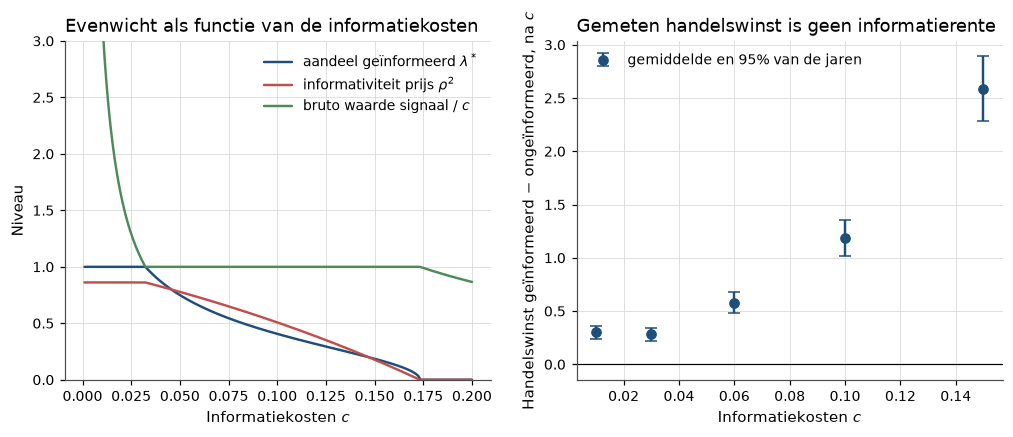

In [5]:
c_grid = np.linspace(0.001, 0.2, 400)
curves = pd.DataFrame([gs_equilibrium(c, a, var_s, var_e, var_z) for c in c_grid],
                      index=c_grid, columns=["lambda", "rho2", "value"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(c_grid, curves["lambda"], label="aandeel geïnformeerd $\\lambda^*$")
axes[0].plot(c_grid, curves["rho2"], label="informativiteit prijs $\\rho^2$")
axes[0].plot(c_grid, curves["value"] / c_grid, label="bruto waarde signaal / $c$")
axes[0].set_ylim(0, 3)
axes[0].set_xlabel("Informatiekosten $c$")
axes[0].set_ylabel("Niveau")
axes[0].set_title("Evenwicht als functie van de informatiekosten")
axes[0].legend()
axes[1].errorbar(sim_gs.index, sim_gs["winst na c (gem.)"], yerr=1.96 * sim_gs["winst na c (sd per jaar)"],
                 fmt="o", capsize=4, label="gemiddelde en 95% van de jaren")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Informatiekosten $c$")
axes[1].set_ylabel("Handelswinst geïnformeerd − ongeïnformeerd, na $c$")
axes[1].set_title("Gemeten handelswinst is geen informatierente")
axes[1].legend()
plt.show()

:::{figure} #cel-llms-en-efficientie-gs
:label: fig-llms-en-efficientie-gs
:width: 100%

Links het evenwicht: onder een drempel van $c$ is iedereen geïnformeerd en is informatie
meer waard dan ze kost; daarboven daalt $\lambda^*$ en is de bruto waarde van het
signaal precies $c$. Rechts steekproeven van één jaar: geïnformeerden verdienen na
aftrek van $c$ elk jaar meer, en meer naarmate informatie duurder is, ook waar ze in nut
niet beter af zijn.
:::

De populatie klopt met [](#thm-llms-en-efficientie-gs), en de informativiteit van de
prijs is in één jaar data goed meetbaar: de geschatte $\rho^2$ ligt gemiddeld binnen
0,003 van de ware waarde, met een spreiding van 0,02 tot 0,04. Het is een tweede moment.

De handelswinst vertelt iets anders dan de naïeve lezing. In alle 2000 jaren verdient
een geïnformeerde na aftrek van $c$ meer dan een ongeïnformeerde, en het voordeel groeit
met de kosten: 0,30 per periode bij $c = 0{,}01$, 2,59 bij $c = 0{,}15$. Toch is in het
inwendige evenwicht niemand in nut beter af: de geïnformeerde neemt grotere posities en
draagt meer risico. Wie de winst van professionele beleggers meet en er een
informatierente in ziet, meet de vergoeding voor kosten en risico, en een krimpend
voordeel bij dalende $c$ is dan een kenmerk van het evenwicht, geen verdwenen
ontdekking.

### (b) Een markt van AI-arbitrageurs met een gedeeld model

Nu [](#thm-llms-en-efficientie-mono) op schaal. Vijftig arbitrageurs schatten elke dag
de waarde van een activum, elk met een fout met eenheidsvariantie en dikke staarten
(Student-$t$ met vier vrijheidsgraden); de prijsfout is hun gemiddelde. Een fractie
$\rho$ deelt één model en dus één fout per dag. We simuleren 2000 jaren van 250 dagen en
kijken naar de dagelijkse prijsfout en naar de slechtste dag per jaar: wat een
risicomanager in één jaar data ziet.

In [6]:
def t_unit(size, df=4):
    """Unit-variance Student-t draws."""
    return rng.standard_t(df, size) * np.sqrt((df - 2) / df)


N_ARB, N_DAYS, N_YEARS = 50, 250, 2000
mono_rows, mono_errors = [], {}
for share in [0.0, 0.1, 0.3, 0.6, 1.0]:
    n_shared = int(round(share * N_ARB))
    err = n_shared * t_unit((N_YEARS, N_DAYS))
    for start in range(0, N_YEARS, 250):                          # chunks keep memory small
        stop = min(start + 250, N_YEARS)
        err[start:stop] += t_unit((stop - start, N_DAYS, N_ARB - n_shared)).sum(-1)
    err /= N_ARB
    worst = err.min(axis=1)
    mono_errors[share] = err
    mono_rows.append({"fractie gedeeld": share,
                      "sd theorie": np.sqrt(share**2 + (1 - share) / N_ARB),
                      "sd simulatie": err.std(),
                      "0,1%-kwantiel": np.quantile(err, 0.001),
                      "slechtste dag (mediaan jaar)": np.median(worst),
                      "slechtste dag (1 op 20 jaar)": np.quantile(worst, 0.05),
                      "kurtosis": stats.kurtosis(err, axis=None)})
mono = pd.DataFrame(mono_rows).set_index("fractie gedeeld")
mono.round(3)

,sd theorie,sd simulatie,"0,1%-kwantiel",slechtste dag (mediaan jaar),slechtste dag (1 op 20 jaar),kurtosis
fractie gedeeld,,,,,,
0.0,0.141,0.141,-0.464,-0.405,-0.558,0.481
0.1,0.167,0.167,-0.612,-0.507,-0.851,2.639
0.3,0.322,0.325,-1.586,-1.181,-2.442,23.452
0.6,0.607,0.608,-3.066,-2.320,-4.584,18.352
1.0,1.000,0.994,-4.934,-3.752,-7.225,13.521


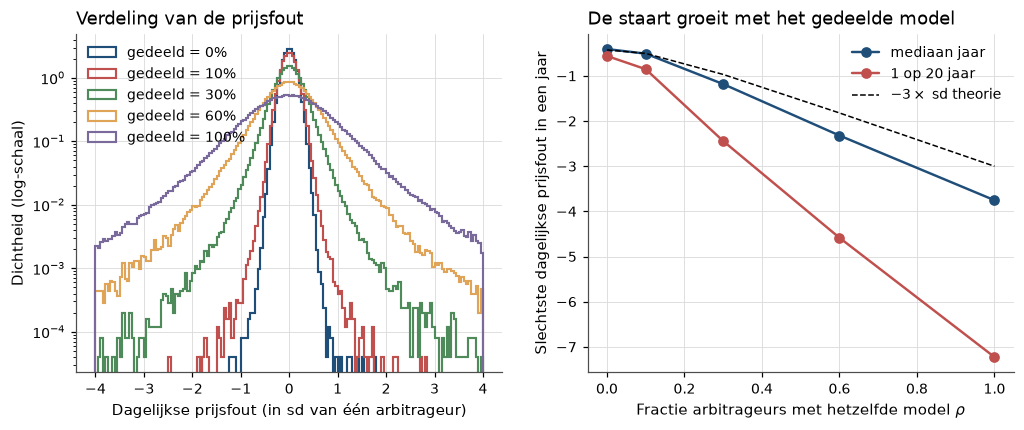

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(-4, 4, 161)
for share, err in mono_errors.items():
    axes[0].hist(err.ravel(), bins=bins, density=True, histtype="step", lw=1.4,
                 label=f"gedeeld = {share:.0%}")
axes[0].set_yscale("log")
axes[0].set_xlabel("Dagelijkse prijsfout (in sd van één arbitrageur)")
axes[0].set_ylabel("Dichtheid (log-schaal)")
axes[0].set_title("Verdeling van de prijsfout")
axes[0].legend()
axes[1].plot(mono.index, mono["slechtste dag (mediaan jaar)"], marker="o", label="mediaan jaar")
axes[1].plot(mono.index, mono["slechtste dag (1 op 20 jaar)"], marker="o", label="1 op 20 jaar")
axes[1].plot(mono.index, -3 * mono["sd theorie"], color="black", ls="--", lw=1, label="$-3 \\times$ sd theorie")
axes[1].set_xlabel("Fractie arbitrageurs met hetzelfde model $\\rho$")
axes[1].set_ylabel("Slechtste dagelijkse prijsfout in een jaar")
axes[1].set_title("De staart groeit met het gedeelde model")
axes[1].legend()
plt.show()

:::{figure} #cel-llms-en-efficientie-mono
:label: fig-llms-en-efficientie-mono
:width: 100%

Elke arbitrageur is in alle scenario's even nauwkeurig, maar hoe groter het gedeelde
deel, hoe breder de verdeling van de prijsfout en hoe dikker de staarten. De slechtste
dag van een jaar volgt de gedeelde fout.
:::

De standaarddeviatie volgt [](#eq-llms-en-efficientie-mono) tot op de derde decimaal:
0,14 zonder gedeeld model, 0,32 met 30% en 0,61 met 60% gedeeld. De staart groeit
sneller. Bij 30% gedeeld gaat het 0,1%-kwantiel van $-0{,}46$ naar $-1{,}59$, en de
slechtste dag die één keer in twintig jaar voorkomt van $-0{,}56$ naar $-2{,}44$. De
kurtosis is het hoogst in een gemengde markt (23 bij 30%): meestal middelen de
onafhankelijke fouten weg, en af en toe maakt het gedeelde model een uitschieter. Bij
100% is de fout één $t_4$-trekking met theoretisch oneindige kurtosis, en de
steekproefwaarde is dan instabiel. Het verraderlijke zit in de mediaan: de slechtste dag
van een gewoon jaar is bij 10% gedeeld $-0{,}51$ tegen $-0{,}41$ zonder. Eén jaar data
laat een beginnende monocultuur meestal niet zien.

### (c) Tienduizend particulieren, dertig jaar

Tot slot advies: 10 000 particulieren over dertig jaar, elk met een eigen marktpad,
onder vier regimes met dezelfde schokken:

- **zelf handelen** (Barber-Odean-achtig): $n = 1 + \text{Poisson}(3)$ aandelen,
  omloop lognormaal met gemiddelde 75% per jaar, geen vergoeding;
- **robo/LLM-adviseur**: gespreid ($n \to \infty$), omloop 10%, vergoeding 0,25%;
- **adviseur met engagement-bias**: gespreid, geen vergoeding, maar omloop
  lognormaal met gemiddelde 100% en een brede staart;
- **markt, kosteloos**: de referentie.

Aannames: $R^f - 1 = 2\%$, $\mu^e = 5\%$, $\sigma_m = 16\%$, $\sigma_\eta = 35\%$,
$\kappa = 2\%$ per eenheid omloop, en lognormale jaarrendementen met de drift van
[](#eq-llms-en-efficientie-groei), zodat de mediaan de formule volgt en de simulatie de
spreiding eromheen laat zien. Welvaart meten we als zekerheidsequivalent jaarrendement
bij CRRA-nut met $\gamma = 3$.

In [8]:
N_INV, YEARS, GAMMA = 10_000, 30, 3.0
RF, MU_E, SIG_M, SIG_ETA, KAPPA = 0.02, 0.05, 0.16, 0.35, 0.02

z_m = rng.standard_normal((N_INV, YEARS))
z_eta = rng.standard_normal((N_INV, YEARS))
n_diy = 1 + rng.poisson(3, N_INV)


def lognormal_turnover(mean, sd_log):
    """Heterogeneous annual turnover with a given cross-sectional mean."""
    return mean * np.exp(sd_log * rng.standard_normal(N_INV) - sd_log**2 / 2)


regimes = {
    "zelf handelen": dict(n=n_diy, tau=lognormal_turnover(0.75, 0.8), fee=0.0),
    "robo/LLM-adviseur": dict(n=np.inf, tau=np.full(N_INV, 0.10), fee=0.0025),
    "engagement-bias": dict(n=np.inf, tau=lognormal_turnover(1.00, 1.0), fee=0.0),
    "markt, kosteloos": dict(n=np.inf, tau=np.zeros(N_INV), fee=0.0),
}

log_returns = {}
for name, r in regimes.items():
    idio_var = SIG_ETA**2 / r["n"]
    drift = RF + MU_E - 0.5 * (SIG_M**2 + idio_var) - KAPPA * r["tau"] - r["fee"]
    log_returns[name] = (drift[:, None] if np.ndim(drift) else drift) + SIG_M * z_m + \
        (np.sqrt(idio_var)[:, None] if np.ndim(idio_var) else np.sqrt(idio_var)) * z_eta

wealth = pd.DataFrame({k: np.exp(v.sum(1)) for k, v in log_returns.items()})
diff = log_returns["zelf handelen"] - log_returns["robo/LLM-adviseur"]
t_own = diff.mean(1) / (diff.std(1, ddof=1) / np.sqrt(YEARS))
advice = pd.DataFrame({
    "mediaan eindvermogen": wealth.median(),
    "1%-kwantiel": wealth.quantile(0.01),
    "5%-kwantiel": wealth.quantile(0.05),
    "95%-kwantiel": wealth.quantile(0.95),
    "CE-rendement (gamma=3)": (wealth.pow(1 - GAMMA).mean() ** (1 / (1 - GAMMA))) ** (1 / YEARS) - 1,
    "P(slechter dan robo)": wealth.lt(wealth["robo/LLM-adviseur"], axis=0).mean(),
})
print(f"zelf handelen vs robo: mediane groeiachterstand {np.median(diff.mean(1)):.2%} per jaar; "
      f"t < -2 bij {np.mean(t_own < -2):.1%} van de particulieren")
advice.round(3)

zelf handelen vs robo: mediane groeiachterstand -2.67% per jaar; t < -2 bij 14.7% van de particulieren


,mediaan eindvermogen,1%-kwantiel,5%-kwantiel,95%-kwantiel,CE-rendement (gamma=3),P(slechter dan robo)
zelf handelen,2.093,0.041,0.148,20.506,-0.094,0.783
robo/LLM-adviseur,4.757,0.611,1.146,20.699,0.027,0.000
engagement-bias,3.248,0.082,0.450,16.125,-0.178,0.842
"markt, kosteloos",5.444,0.699,1.312,23.690,0.032,0.000


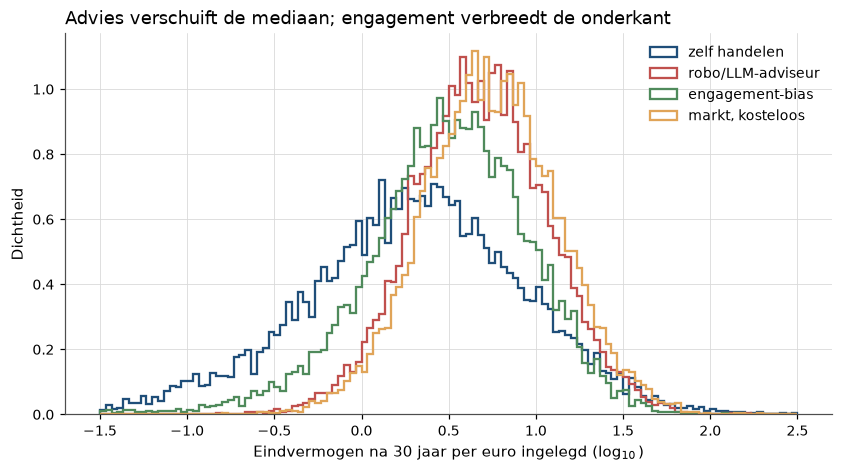

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(-1.5, 2.5, 121)
for name in regimes:
    ax.hist(np.log10(wealth[name]), bins=bins, histtype="step", lw=1.5, density=True, label=name)
ax.set_xlabel("Eindvermogen na 30 jaar per euro ingelegd ($\\log_{10}$)")
ax.set_ylabel("Dichtheid")
ax.set_title("Advies verschuift de mediaan; engagement verbreedt de onderkant")
ax.legend()
plt.show()

:::{figure} #cel-llms-en-efficientie-advies
:label: fig-llms-en-efficientie-advies
:width: 90%

Eindvermogen van 10 000 gesimuleerde particulieren. Spreiding en lage omloop schuiven de
verdeling naar rechts; de adviseur met engagement-bias behoudt de spreiding maar
verliest via de handel, het meest bij wie het meest handelt.
:::

De mediane zelfhandelaar eindigt met 2,09 euro per ingelegde euro, met de robo-adviseur
4,76, in de kosteloze markt 5,44. De verhouding 0,44 ligt dicht bij de $e^{-0{,}9} =
0{,}41$ uit [](#eq-llms-en-efficientie-groei). Van de zelfhandelaars eindigt 78%
slechter dan met de robo-adviseur, en onderaan is het verschil het grootst: een
5%-kwantiel van 0,15 tegen 1,15.

De adviseur met engagement-bias laat Santa-Clara's verwachting in getallen zien. Zijn
mediane klant (3,25) en zijn 1%- en 5%-kwantiel (0,08 en 0,45) doen het beter dan wie
zelf handelt, omdat de spreiding blijft. Maar 84% van zijn klanten doet het slechter dan
met de robo-adviseur, en het zekerheidsequivalente rendement ($-17{,}8\%$ per jaar) is
lager dan dat van zelf handelen ($-9{,}4\%$). Dat komt uit de uiterste staart: wie het
platform tot een omloop van tien keer per jaar of meer verleidt, verliest in dertig jaar
vrijwel alles, en een belegger met $\gamma = 3$ weegt die uitkomsten zwaar. Betere
mediaan, slechtere staart.

En de steekproef: slechts 14,7% van de zelfhandelaars zou na dertig jaar met een
$t$-toets op de eigen jaarrendementen zien dat hij achterblijft. Bijna drie procentpunt
per jaar is groot voor het vermogen en klein naast de 17,5 procentpunt idiosyncratische
volatiliteit van vier aandelen. Wie alleen uit eigen ervaring leert, leert dit niet: het
2%-motief, op huishoudniveau.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** (1) Eisfeldt, Schubert & Zhang, *Generative AI and Firm Values*, NBER
Working Paper 31222, 2023 {cite}`EisfeldtSchubertZhang2023`. (2) De halfwaardetijd van
informatie zoals samengevat door Santa-Clara {cite}`SantaClara2026`, gemeten met de
autocorrelatie- en variance-ratiotoetsen van
[de lecture over efficiënte markten](#02-06-efficiente-markten)
{cite}`LoMacKinlay1988`. (3) Lopez-Lira & Tang {cite}`LopezLiraTang2023` repliceren we
niet.

**Wat.** (1) Het meerrendement van bedrijven met een hoge blootstelling aan
generatieve AI ten opzichte van bedrijven met een lage, na de lancering van ChatGPT
op 30 november 2022; volgens hun samenvatting *"0.4% higher on a daily basis"* voor
hun long-short portefeuille. (2) De dagelijkse eerste-orde-autocorrelatie en
$VR(5)$ van het marktrendement per decennium.

**Data hier.** (1) Dagelijkse gecorrigeerde slotkoersen van 50 grote Amerikaanse
aandelen, 2002-01 t/m 2026-07, via `hap.data.yahoo(...)`, en het marktrendement van
French via `hap.data.market_daily()`. De indeling is van ons, vastgelegd vóór de
berekening: *hoog* zijn software, IT-beveiliging, internetplatforms en
betalingsnetwerken, waar het personeel vooral code, tekst en data verwerkt (ADBE,
CRM, NOW, PANW, FTNT, GOOGL, MA, V); *laag* zijn bedrijven met overwegend fysiek
werk in detailhandel, horeca, transport, energie, industrie en consumptiegoederen
(CMG, CPRT, CSX, CTAS, CVX, DE, FAST, KO, MNST, NKE, ODFL, ORLY, PG, ROST, SBUX,
SHW, TJX, TSCO, UNP, WMT). Chips en hardware (AAPL, ANET, APH, AVGO, LRCX, NVDA,
QCOM, SMCI) vallen buiten het verschil omdat hun blootstelling via het *product*
loopt, niet via het personeel; de overige veertien aandelen (financiële instellingen,
zorg, AMZN, NFLX, TSLA) zijn niet eenduidig in te delen en doen niet mee. Marktmodel
op dagen $[-280, -31]$, eventvenster $[0, +10]$ met dag 0 = 30 november 2022.
(2) French dagelijkse marktrendementen 1930–2026-07. (3) Geen: nieuwskoppen en
LLM-toegang zijn niet gratis; we noemen hun getallen hierboven letterlijk.

**Verschil met het origineel.** Eisfeldt, Schubert en Zhang meten blootstelling per
bedrijf uit de beroepensamenstelling van het personeel en de taken die generatieve
AI kan overnemen, voor alle Amerikaanse beursgenoteerde bedrijven; wij hebben 28
aandelen in twee groepen, ingedeeld naar sector, en bovendien geselecteerd omdat ze
*nu* groot zijn. Hun portefeuilles zijn breed en gewogen; de onze gelijkgewogen en
klein, zodat sectorschokken niet wegmiddelen. Voor (2) is het CRSP-marktindex van
French in de vroege decennia een index met veel dun verhandelde aandelen, zodat
niet-synchrone handel de autocorrelatie opdrijft.

**Verwachte afwijking.** (1) Het teken moet gelijk zijn: een positief CAR$[0,+10]$
van *hoog* minus *laag*, van de orde van enkele procenten (hun 0,4% per dag over elf
handelsdagen is ruim 4%). Met twee kleine portefeuilles en één eventdatum is het
95%-interval breed; een $t$-waarde onder 2 is geen verrassing, een negatief teken wel.
(2) De dagelijkse autocorrelatie van de markt is in de vroege decennia positief en
significant en daalt over de decennia naar ongeveer nul: de hoogste waarde ligt vóór
1990, en na 2000 ligt ze in elk decennium binnen 0,1 van nul.
```

### (1) De lancering van ChatGPT als event

In [10]:
GROUPS = {
    "hoog": ["ADBE", "CRM", "NOW", "PANW", "FTNT", "GOOGL", "MA", "V"],
    "hardware": ["AAPL", "ANET", "APH", "AVGO", "LRCX", "NVDA", "QCOM", "SMCI"],
    "laag": ["CMG", "CPRT", "CSX", "CTAS", "CVX", "DE", "FAST", "KO", "MNST", "NKE",
             "ODFL", "ORLY", "PG", "ROST", "SBUX", "SHW", "TJX", "TSCO", "UNP", "WMT"],
}
OTHER = ["AMZN", "BAC", "BRK-B", "DHR", "DXCM", "EW", "GILD", "IDXX", "ISRG", "NFLX",
         "TSLA", "UNH", "WFC", "WRB"]
TICKERS = sorted(sum(GROUPS.values(), OTHER))
assert len(TICKERS) == 50

prices = hap_data.yahoo(TICKERS, start="2002-01-01", end="2026-08-01")
market = hap_data.market_daily()["Mkt"]
rets = prices.pct_change(fill_method=None).loc["2010-01-01":]
dates = rets.index.intersection(market.index)
rets, mkt = rets.loc[dates], market.loc[dates]

port = pd.DataFrame({g: rets[t].mean(axis=1) for g, t in GROUPS.items()})
port["hoog - laag"] = port["hoog"] - port["laag"]
EVENT = dates.searchsorted(pd.Timestamp("2022-11-30"))
print(f"dag 0 = {dates[EVENT]:%Y-%m-%d}; {len(dates)} handelsdagen {dates[0]:%Y-%m-%d} t/m {dates[-1]:%Y-%m-%d}")

dag 0 = 2022-11-30; 4169 handelsdagen 2010-01-04 t/m 2026-07-31


In [11]:
def market_model_car(y, m, i0, lo=0, hi=10, est=(-280, -31)):  # TODO: naar hap.stats
    """CAR over [i0+lo, i0+hi] from a market model estimated on [i0+est0, i0+est1].

    The variance includes estimation error in alpha and beta (MacKinlay 1997).
    Returns CAR, its standard error, beta and the abnormal returns from est0 onwards.
    """
    e = np.arange(i0 + est[0], i0 + est[1] + 1)
    X = np.column_stack([np.ones(len(e)), m[e]])
    xtx_inv = np.linalg.inv(X.T @ X)
    coef = xtx_inv @ X.T @ y[e]
    resid = y[e] - X @ coef
    s2 = resid @ resid / (len(e) - 2)
    win = np.arange(i0 + lo, i0 + hi + 1)
    g = np.array([len(win), m[win].sum()])
    car = (y[win] - coef[0] - coef[1] * m[win]).sum()
    path = y[i0 + est[0]:] - coef[0] - coef[1] * m[i0 + est[0]:]
    return car, np.sqrt(s2 * (len(win) + g @ xtx_inv @ g)), coef[1], path


m_arr = mkt.to_numpy()
event_rows = {}
for col in port.columns:
    car, se, beta, _ = market_model_car(port[col].to_numpy(), m_arr, EVENT)
    event_rows[col] = {"CAR[0,+10]": car, "SE": se, "t": car / se, "beta": beta}
event_table = pd.DataFrame(event_rows).T
event_table.round(4)

,"CAR[0,+10]",SE,t,beta
hoog,-0.0040,0.0329,-0.1219,1.3307
hardware,0.0222,0.0360,0.6180,1.4463
laag,-0.0055,0.0182,-0.3032,0.8120
hoog - laag,0.0015,0.0411,0.0367,0.5188


Met één eventdatum klopt de standaardfout uit het schattingsvenster alleen als dat
venster representatief is. Een eerlijkere meetlat is de verdeling van hetzelfde CAR in
alle niet-overlappende elfdaagse vensters van 2011 tot het event, elk met een eigen
marktmodel.

In [12]:
y_ls = port["hoog - laag"].to_numpy()
first = dates.searchsorted(pd.Timestamp("2011-03-01"))
placebo_days = [i for i in range(first, EVENT - 11, 11) if np.isfinite(y_ls[i - 280:i + 11]).all()]
placebo = np.array([market_model_car(y_ls, m_arr, i)[0] for i in placebo_days])
car_event = event_table.loc["hoog - laag", "CAR[0,+10]"]
pd.Series({
    "aantal placebovensters": len(placebo),
    "sd placebo-CAR": placebo.std(ddof=1),
    "SE uit marktmodel (event)": event_table.loc["hoog - laag", "SE"],
    "CAR event / sd placebo": car_event / placebo.std(ddof=1),
    "percentiel van event in placebo": (placebo < car_event).mean(),
    "CAR[-20,-1], vóór het event": market_model_car(y_ls, m_arr, EVENT, -20, -1)[0],
}).round(4)

aantal placebovensters             268.0000
sd placebo-CAR                       0.0339
SE uit marktmodel (event)            0.0411
CAR event / sd placebo               0.0446
percentiel van event in placebo      0.5112
CAR[-20,-1], vóór het event         -0.0847
dtype: float64

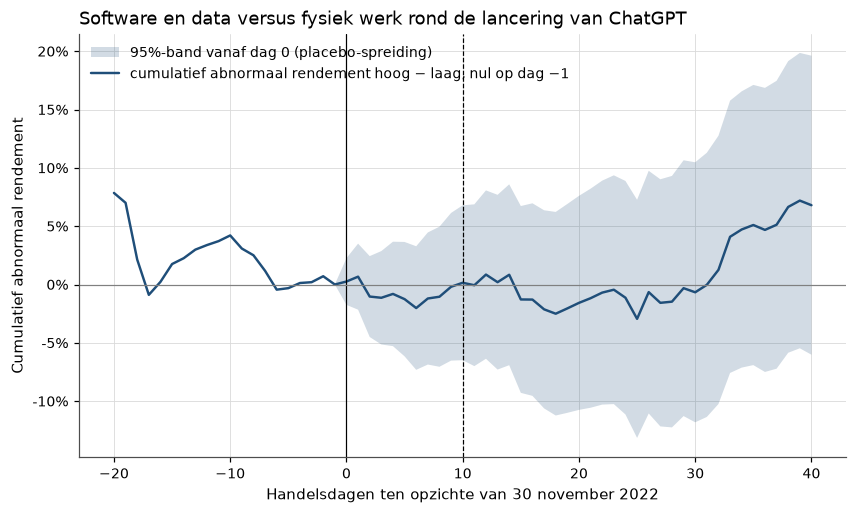

In [13]:
_, _, _, path = market_model_car(y_ls, m_arr, EVENT)
tau = np.arange(-280, len(path) - 280)
keep = (tau >= -20) & (tau <= 40)
cum = np.cumsum(path[keep]) - np.cumsum(path[keep])[tau[keep] == -1]      # zero at day -1
sd_day = placebo.std(ddof=1) / np.sqrt(11)
band = 1.96 * sd_day * np.sqrt(np.clip(tau[keep] + 1, 0, None))

fig, ax = plt.subplots()
ax.fill_between(tau[keep], cum - band, cum + band, alpha=0.2, label="95%-band vanaf dag 0 (placebo-spreiding)")
ax.plot(tau[keep], cum, label="cumulatief abnormaal rendement hoog − laag, nul op dag −1")
ax.axvline(0, color="black", lw=0.8)
ax.axvline(10, color="black", lw=0.8, ls="--")
ax.axhline(0, color="grey", lw=0.8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Handelsdagen ten opzichte van 30 november 2022")
ax.set_ylabel("Cumulatief abnormaal rendement")
ax.set_title("Software en data versus fysiek werk rond de lancering van ChatGPT")
ax.legend(loc="upper left")
plt.show()

:::{figure} #cel-llms-en-efficientie-chatgpt
:label: fig-llms-en-efficientie-chatgpt
:width: 90%

Cumulatief abnormaal rendement van acht software-, platform- en betalingsbedrijven minus
twintig bedrijven met overwegend fysiek werk, nul op de dag vóór de lancering van
ChatGPT. De band groeit met de wortel van de horizon en is geschaald op de spreiding van
268 elfdaagse placebovensters uit 2011–2022; de gestreepte lijn markeert het eind van
$[0,+10]$.
:::

Het teken is positief, zoals verwacht, maar daar houdt de overeenstemming op. Het
CAR$[0,+10]$ van hoog minus laag is 0,15% (standaardfout 4,1 procentpunt, $t = 0{,}04$),
op het 51e percentiel van 268 placebovensters (spreiding 3,4 procentpunt). De verwachte
ruim 4% halen we niet, en het teken is niet robuust: $-1{,}25\%$ over $[0,+5]$,
$-1{,}57\%$ over $[0,+20]$, $+1{,}5\%$ met de hardwareaandelen erbij
([](#ex-llms-en-efficientie-3)). In de vier weken vóór de lancering had hoog minus laag
al 8,5% abnormaal verloren; pas in januari 2023 loopt het verschil op tot ongeveer 7%,
binnen de band.

Drie redenen. Ten eerste de steekproef: met een ruis van 3,4 procentpunt over elf dagen
zou zelfs een effect van 4% hier een $t$ van ruim 1 geven, dus ook het resultaat van
Eisfeldt, Schubert en Zhang zou in deze opzet niet significant zijn — het 2%-motief in
eventtijd. Ten tweede meten zij blootstelling per bedrijf uit beroepen en taken, met
*"wide variation across and within industries"*; een sectorindeling mist dat. Ten derde
valt het event in de koersdaling van technologieaandelen van 2022. De replicatie zegt
dus niet dat hun effect niet bestaat, maar dat het met gratis data van 50 aandelen niet
te zien is.

### (2) Snellere prijzen: autocorrelatie per decennium

In [14]:
r_daily = np.log1p(hap_data.market_daily()["Mkt"])
decade_rows = []
for start in range(1930, 2030, 10):
    x = r_daily.loc[f"{start}-01-01":f"{start + 9}-12-31"]
    rho1 = x.autocorr(1)
    vr = hap.stats.variance_ratio(x, 5)
    decade_rows.append({
        "decennium": f"{start}s", "dagen": len(x), "rho1": rho1, "SE": 1 / np.sqrt(len(x)),
        "VR(5)": vr["vr"], "z VR(5) robuust": vr["z2"],
        "vol (jaar)": x.std() * np.sqrt(252),
        "halfwaardetijd (uur)": 6.5 * np.log(2) / -np.log(rho1) if rho1 > 0 else np.nan,
    })
decades = pd.DataFrame(decade_rows).set_index("decennium")
decades.round(3)

,dagen,rho1,SE,VR(5),z VR(5) robuust,vol (jaar),halfwaardetijd (uur)
decennium,,,,,,,
1930s,2988,0.052,0.018,1.094,1.566,0.276,1.524
1940s,2918,0.157,0.019,1.204,2.645,0.127,2.437
1950s,2598,0.127,0.020,1.100,1.604,0.101,2.183
1960s,2489,0.202,0.020,1.374,3.831,0.099,2.815
1970s,2526,0.289,0.020,1.513,8.421,0.133,3.631
1980s,2528,0.131,0.020,1.160,1.294,0.155,2.214
1990s,2528,0.078,0.020,1.102,1.529,0.133,1.763
2000s,2515,-0.062,0.020,0.837,-2.078,0.223,NaN
2010s,2516,-0.038,0.020,0.921,-1.086,0.152,NaN


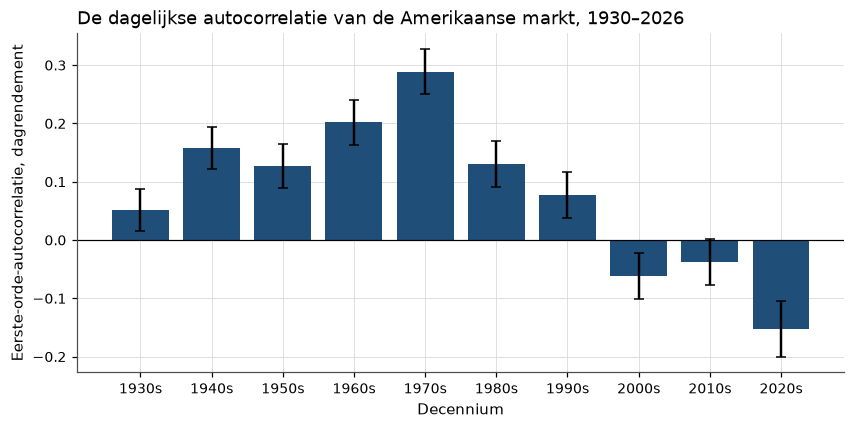

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(decades.index, decades["rho1"], yerr=1.96 * decades["SE"], capsize=3, color=hap.plotting.COLORS[0])
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Decennium")
ax.set_ylabel("Eerste-orde-autocorrelatie, dagrendement")
ax.set_title("De dagelijkse autocorrelatie van de Amerikaanse markt, 1930–2026")
plt.show()

:::{figure} #cel-llms-en-efficientie-autocorr
:label: fig-llms-en-efficientie-autocorr
:width: 85%

Eerste-orde-autocorrelatie van het dagelijkse log-marktrendement (French, CRSP
value-weighted) per decennium, met 95%-interval onder de nulhypothese van
onafhankelijkheid.
:::

De autocorrelatie is in de eerste zeven decennia positief en significant, piekt in de
jaren zeventig op 0,29 (standaardfout 0,02, $VR(5) = 1{,}51$) en daalt daarna: 0,13 in
de jaren tachtig, 0,08 in de jaren negentig, en $-0{,}06$ en $-0{,}04$ na 2000. Het
eerste deel van de verwachting klopt: het maximum ligt vóór 1990. Het tweede niet: de
jaren 2020 hebben $-0{,}15$, verder dan 0,1 van nul. Dat komt vrijwel geheel uit de
coronacrash: 2020 alleen geeft $-0{,}34$, 2021 tot en met juli 2026 $-0{,}02$, en de
rangcorrelatie over het decennium is $-0{,}04$; de robuuste variance-ratiotoets vindt
geen significante afwijking ($z = -1{,}04$).

Met [](#eq-llms-en-efficientie-ar1) vertaald is de halfwaardetijd in de jaren zeventig
3,6 handelsuur en in de jaren negentig 1,8. Dat is een bovengrens voor traagheid, geen
meting ervan: de CRSP-index bevatte veel aandelen met een slotkoers van uren eerder, en
niet-synchrone handel geeft precies dit patroon. De daling valt samen met de komst van
indexfutures (vanaf 1982) en ETF's (vanaf 1993). Het resultaat is verenigbaar met
snellere informatieverwerking, maar bewijst haar niet.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Grossman en Stiglitz lossen de paradox uit [de lecture over
efficiënte markten](#02-06-efficiente-markten) op: goedkopere informatie trekt meer
geïnformeerden aan, maakt prijzen informatiever en laat het gemeten voordeel krimpen,
zoals Lopez-Lira en Tang later rapporteren. Prijzen werden sneller: de dagelijkse
autocorrelatie van de markt daalde van 0,29 in de jaren zeventig naar vrijwel nul. En
robo-advies leverde beter gespreide portefeuilles en minder gedragsvertekening op.

**Waar het breekt.** Bij het aggregaat en bij de meetbaarheid. Snellere prijzen maakten
de markt niet rustiger: de jaarvolatiliteit van het dagrendement was 10% in de jaren
vijftig en zestig, en 22% en 21% in de jaren 2000 en 2020. Grossman-Stiglitz zegt hoe
dicht een prijs bij het signaal ligt, niets over stromen die het niveau verplaatsen. En
op het ene moment waarop we precies weten wanneer de nieuwe machine kwam, meten we met
50 aandelen geen koerseffect (CAR 0,15%, $t = 0{,}04$). De speculatieve helft, de
monocultuur en de adviseur die per transactie wordt betaald, heeft nog geen toets.

**Risico of vergissing?** In de Chicago-lezing is de koersreactie op ChatGPT een
herwaardering van kasstromen en discontovoeten, is het voordeel van geïnformeerden een
vergoeding voor kosten en risico (simulatie (a)), en is crashrisico uit gedeelde
modellen beprijsd risico. In de Yale-lezing is dezelfde reactie aandacht en geldstroom
{cite}`BarberHuangOdeanSchwarz2022`, en is de monocultuur de crowding van
{cite:t}`Stein2009`: een vergissing die niemand ziet. Scheiden zou kunnen met de
posities en modellen van AI-gedreven fondsen en met de kasstromen van blootgestelde
bedrijven na 2022; het eerste is niet openbaar, het tweede nog te kort. Santa-Clara's
les: *"Everything I made that lasted came from bearing risk that was priced. Everything
I lost came from thinking I knew something the price did not"* {cite}`SantaClara2026`.
Een taalmodel dat vertelt wat er in een krantenkop staat, vertelt wat de prijs al weet.

**Wat er daarna kwam.** Hier eindigt de geschiedenis en begint de balans: welke
uitspraken na anderhalve eeuw overeind staan, is het onderwerp van
[](#08-38-wat-we-weten).

## Oefeningen

:::{exercise}
:label: ex-llms-en-efficientie-1

**Ruis en de grens van volledige deelname.** Gebruik de parameters van het
toy-voorbeeld ($a = 2$, $\sigma^2_s = \sigma^2_\varepsilon = 1$, $\sigma^2_z = 0{,}04$).

1. Verdubbel de ruis in het aanbod naar $\sigma^2_z = 0{,}08$ bij $c = \ln(1{,}5)/4$.
   Bereken met de hand $\lambda^*$ en $\rho^2$ en leg uit waarom het ene verandert en
   het andere niet.
2. Leid af bij welke informatiekosten $c^*$ iedereen geïnformeerd wordt, en bereken
   $c^*$ voor het toy-voorbeeld.
3. Controleer beide antwoorden met `gs_equilibrium`.
:::

:::{solution} ex-llms-en-efficientie-1
:class: dropdown

**(1)** Nu is $m = 0{,}32$ en nog steeds $k = 0{,}5$, dus $\rho^2 = 0{,}5$ ongewijzigd
en $\lambda^* = \sqrt{0{,}32} = 0{,}566$. Meer ruis maakt informatie aantrekkelijker; er
treden beleggers toe tot de informativiteit weer op het niveau staat waar informatie
precies $c$ waard is.

**(2)** $\lambda^* = 1$ zodra $m(1-k)/k \ge 1$, dus $k \le m/(1+m)$. Met $k =
(\sigma^2_\varepsilon/\sigma^2_s)(e^{2ac}-1)$ geeft dat
$c^* = \ln\bigl(1 + \tfrac{\sigma^2_s}{\sigma^2_\varepsilon}\tfrac{m}{1+m}\bigr)/(2a)$.
Voor $m = 0{,}16$: $c^* = \ln(1{,}1379)/4 = 0{,}0323$.

In [16]:
print("sigma_z^2 = 0.08:", np.round(gs_equilibrium(np.log(1.5) / 4, a, var_s, var_e, 0.08)[:2], 4))
m_toy = a**2 * var_e**2 * var_z / var_s
c_star = np.log1p(var_s / var_e * m_toy / (1 + m_toy)) / (2 * a)
print(f"c* = {c_star:.4f}; lambda net onder en boven c*:",
      [round(float(gs_equilibrium(c, a, var_s, var_e, var_z)[0]), 4) for c in (c_star * 0.99, c_star * 1.01)])

sigma_z^2 = 0.08: [0.5657 0.5   ]
c* = 0.0323; lambda net onder en boven c*: [1.0, 0.9939]


De oefening laat zien waarom goedkope informatie de prijs alleen tot een grens
informatiever maakt: onder $c^*$ doet iedereen al mee, en wat de prijs dan nog
tegenhoudt is risicoaversie, geen kostprijs.
:::

:::{exercise}
:label: ex-llms-en-efficientie-2

**Relatieve en geaggregeerde fouten.** Een model maakt in elk van $K$ aandelen een fout
$e_j = g + \eta_j$, met $\Var(g) = \sigma^2_g$ (een fout die alle aandelen raakt) en
$\eta_j$ onafhankelijk met variantie $\sigma^2_\eta$.

1. Leid de variantie af van de fout in een gelijkgewogen marktportefeuille en in een
   long-short portefeuille die $1/(K/2)$ long gaat in de eerste helft en $1/(K/2)$
   short in de tweede helft.
2. Neem $\sigma_g = \sigma_\eta = 1$ en $K = 2, 10, 100, 1000$. Controleer met een
   simulatie van 20 000 dagen.
3. Wat betekent dit voor Santa-Clara's bewering dat machines relatieve prijzen
   efficiënter maken, maar het aggregaat niet?
:::

:::{solution} ex-llms-en-efficientie-2
:class: dropdown

**(1)** Marktportefeuille: $\bar e = g + \bar\eta$, variantie $\sigma^2_g +
\sigma^2_\eta/K$. Long-short: $g$ valt weg, en de fout is het verschil van twee
gemiddelden van $K/2$ onafhankelijke $\eta$'s, variantie $4\sigma^2_\eta/K$.

**(2)**

In [17]:
rows = []
for K in [2, 10, 100, 1000]:
    g = rng.standard_normal((20_000, 1))
    eta = rng.standard_normal((20_000, K))
    e = g + eta
    rows.append({"K": K, "markt sim": e.mean(1).var(), "markt theorie": 1 + 1 / K,
                 "long-short sim": (e[:, :K // 2].mean(1) - e[:, K // 2:].mean(1)).var(),
                 "long-short theorie": 4 / K})
pd.DataFrame(rows).set_index("K").round(3)

,markt sim,markt theorie,long-short sim,long-short theorie
K,,,,
2,1.498,1.500,2.013,2.000
10,1.111,1.100,0.391,0.400
100,1.011,1.010,0.040,0.040
1000,1.023,1.001,0.004,0.004


**(3)** De relatieve fout gaat met $1/K$ naar nul, de geaggregeerde blijft $\sigma^2_g$.
Een beter model verkleint $\sigma^2_\eta$, maar geen aantal aandelen of arbitrageurs
haalt $g$ weg: het aggregaat wordt alleen efficiënter als de modellen verschillender
worden, niet beter.
:::

:::{exercise}
:label: ex-llms-en-efficientie-3

**Hoe gevoelig is de ChatGPT-event study?** Gebruik `port`, `m_arr`, `EVENT` en
`market_model_car` uit de replicatie.

1. Bereken het CAR van *hoog* minus *laag* voor de vensters $[0,+5]$, $[0,+10]$ en
   $[0,+20]$, en voor dag $-5$ tot $-1$ (een placebo vóór het event).
2. Herhaal $[0,+10]$ met de hardwareaandelen toegevoegd aan *hoog*.
3. Vergelijk elk CAR met de spreiding van placebo-CAR's van dezelfde lengte. Welke
   conclusie overleeft alle keuzes?
:::

:::{solution} ex-llms-en-efficientie-3
:class: dropdown

In [18]:
def placebo_sd(y, length):
    days = [i for i in range(first, EVENT - length, length) if np.isfinite(y[i - 280:i + length]).all()]
    return np.std([market_model_car(y, m_arr, i, 0, length - 1)[0] for i in days], ddof=1)


hoog_plus = rets[GROUPS["hoog"] + GROUPS["hardware"]].mean(axis=1) - port["laag"]
variants = {"hoog - laag": y_ls, "hoog+hardware - laag": hoog_plus.to_numpy()}
rows = []
for name, y in variants.items():
    for lo, hi in [(-5, -1), (0, 5), (0, 10), (0, 20)]:
        if name != "hoog - laag" and (lo, hi) != (0, 10):
            continue
        car, se, _, _ = market_model_car(y, m_arr, EVENT, lo, hi)
        rows.append({"portefeuille": name, "venster": f"[{lo},{hi}]", "CAR": car, "SE model": se,
                     "sd placebo": placebo_sd(y, hi - lo + 1)})
sens = pd.DataFrame(rows)
sens["CAR / sd placebo"] = sens["CAR"] / sens["sd placebo"]
sens.round(4)

,portefeuille,venster,CAR,SE model,sd placebo,CAR / sd placebo
0,hoog - laag,"[-5,-1]",0.0044,0.0274,0.0236,0.1865
1,hoog - laag,"[0,5]",-0.0125,0.0301,0.0253,-0.4952
2,hoog - laag,"[0,10]",0.0015,0.0411,0.0339,0.0446
3,hoog - laag,"[0,20]",-0.0157,0.0578,0.0429,-0.3673
4,hoog+hardware - laag,"[0,10]",0.0146,0.0352,0.0285,0.5140


Geen variant komt verder dan ruim een halve placebo-standaarddeviatie van nul. Het teken
wisselt met het venster, de hardwareaandelen maken het $+1{,}46\%$, en de placebo vóór
het event ($+0{,}44\%$) is niet te onderscheiden van de echte vensters. Wat alle keuzes
overleeft, is de omvang van de ruis, ongeveer drie procentpunt over elf dagen: een event
study met één datum en een paar dozijn aandelen kan een effect van de gepubliceerde
omvang bevestigen noch verwerpen.
:::